# COMMEMI 2D-4：静位移下 OT vs MSE 反演对比

使用 `MT2DTrueModels.create_commemi_2d4` 生成标准模型，在合成数据上施加静位移后，
分别用 **6D OT**（`mode="6dot"`）与 **MSE**（`mode="mse"`）反演，并对比收敛曲线与视电阻率拟合。

In [1]:
import os
import sys
import torch
from pathlib import Path
import numpy as np

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "mt2d_inv" / "__init__.py").is_file():
            return p
    raise RuntimeError("Cannot find project root (expected src/mt2d_inv/__init__.py)")

root_path = str(_find_project_root(Path.cwd()))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

from src.mt2d_inv import MT2DInverterWeightedCost, MT2DTrueModels
from src.mt2d_inv.io import ExperimentLogger
from src.mt2d_inv.plotting import (
    plot_ot_mse_convergence,
    plot_ot_mse_convergence_from_dirs,
    plot_rho_fitting_from_npz,
    plot_ot_mse_pseudosection_from_npz,
)

logger = ExperimentLogger(
    model_tag="test",
    output_root=Path("test_results"),
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device}")
print(f"Project root: {root_path}")

Running on cuda
Project root: /home/liuxr/论文绘图


In [3]:
# 1) Build COMMEMI 2D-i true model
yn, zn, nza, sig_true = MT2DTrueModels.create_commemi_2d4(
    nza=10,
    device=device, 
)

# 2) Survey setup
freqs = torch.logspace(0, -5, 30, device=device)
stations = torch.linspace(-15000.0, 15000.0, 21, device=device)

print(f"Grid (nz, ny): {(len(zn)-1, len(yn)-1)}")
print(f"Stations: {len(stations)}, Freqs: {len(freqs)}")

Grid (nz, ny): (40, 40)
Stations: 21, Freqs: 30


✓ Random seed set: 123
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.0100, scale=0.9, reach=None
Generating 2D MT synthetic data...
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ 2D data error propagation completed
Computing data weights (Target Noise: 1.0%)
  - Resistivity Error Floor: 1.0%
  - Phase Error Floor:       0.500 deg
✓ MSE data weights normalized (mean): scale=5.844213e+01
✓ Synthetic data generated
  -> Impedance noise level: 1.0% (gaussian)
✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


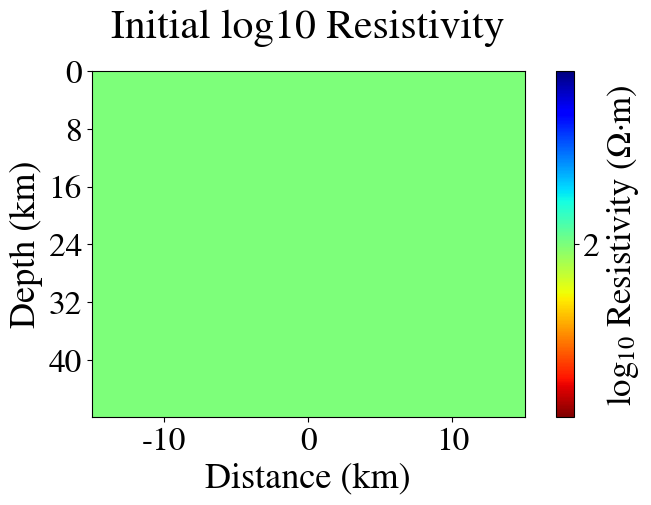

In [4]:
# 3) Inverter + synthetic data
inv = MT2DInverterWeightedCost(
    yn=torch.tensor(yn, dtype=torch.float64, device=device),
    zn=torch.tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs,
    stations=stations,
    device=device,
    random_seed=123,
    te_weight=3.0,
    tm_weight=1.0,
    data_loss_scale=10,
)
inv.set_forward_operator()
inv.sig_true = sig_true
inv.create_synthetic_data(noise_level=0.01,
                        noise_type="gaussian",
                        static_shift_std=0.15,   # 0.15 会导致电阻率发生约半个量级的剧烈上下平移
                        shift_modes=("xy", "yx"),# 作用于双极化模式 (TM 模式通常对畸变最敏感)
                        shift_stations="middle",
                        shift_ratio = 0.2)
inv.initialize_model(initial_sigma=0.01)
inv.plot_initial_model(clip_to_stations=True, ylim=[50, 0],synthetic_figwidth_scale=2.0)

In [5]:
# 4a) OT 反演 (6dot)
inv.initialize_model(initial_sigma=0.01)
final_sigma_ot = inv.run_inversion(
    n_epochs=3,
    mode="6dot",
    progress_interval=20,
    current_lambda=0.01,
    use_adaptive_lambda=True,
    lr=0.05,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    profile_timing=False,
)
print("OT inversion done")
print(final_sigma_ot.min().item(), final_sigma_ot.max().item())

✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m
✓ Optimizer: AdamW, lr=0.05, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.05, weight_decay=0.0
Epoch 1/3 [  33.3%]
  Elapsed: 0:00:02 | Remaining: ~0:00:02 | ETA: 04:44:01
  Epoch time: 1.41s | Avg: 1.41s
  Total: 5.6708e-01 | Data(6dot): 5.6708e-01
  [Cost weights] w_s=1.000, w_f=1.000, w_d=(1.0, 1.0, 1.0, 1.0)
  Misfit(RMS χ²): 65.192 | Rough: 0.00e+00 | Lam: 0.0100000
  OT-distance(6D, view-only): 5.670822e+01
  GradNorms: |g_d|=nan | |λ·g_m|=nan
Epoch 3/3 [ 100.0%]
  Elapsed: 0:00:04 | Remaining: ~0:00:00 | ETA: 04:44:00
  Epoch time: 1.36s | Avg: 1.38s
  Total: 4.9217e-01 | Data(6dot): 4.8824e-01
  Misfit(RMS χ²): 60.339 | Rough: 3.93e-01 | Lam: 0.0100000
  OT-distance(6D, view-only): 4.882352e+01
  GradNorms: |g_d|=nan | |λ·g_m|=nan
Inversion completed.
OT inversion done
1e-10 0.011621038567520751


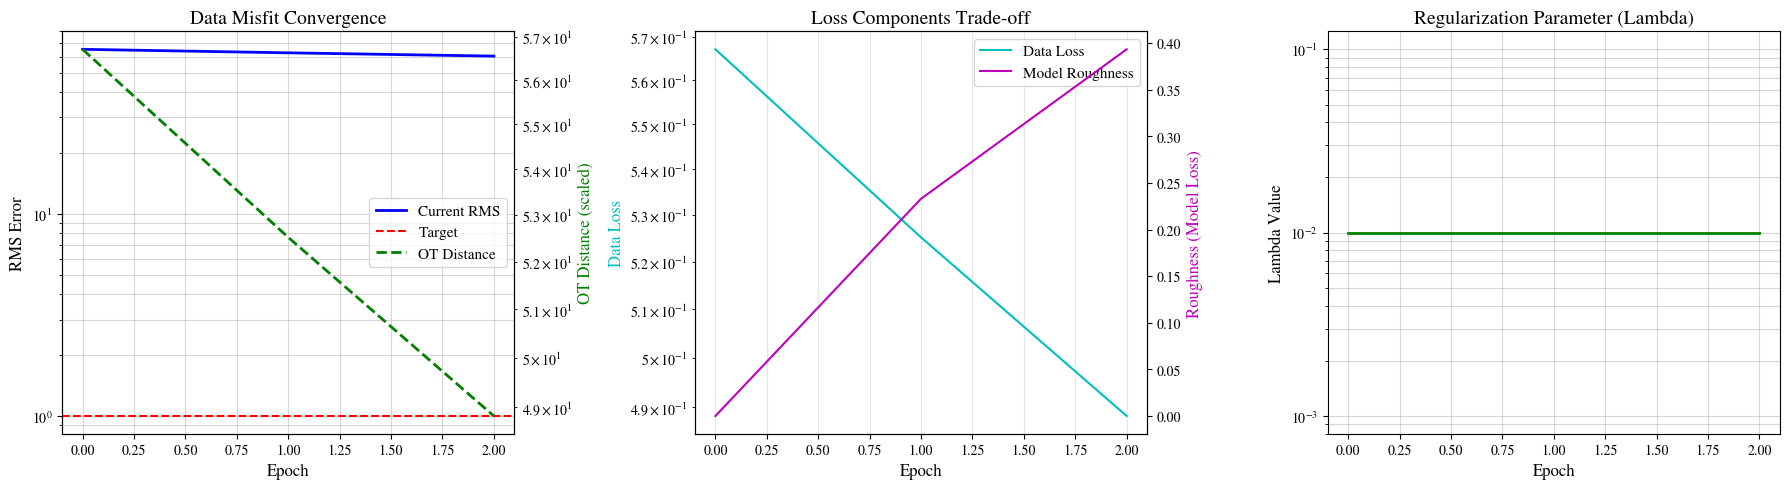

Model structural similarity (SSIM): 0.5345


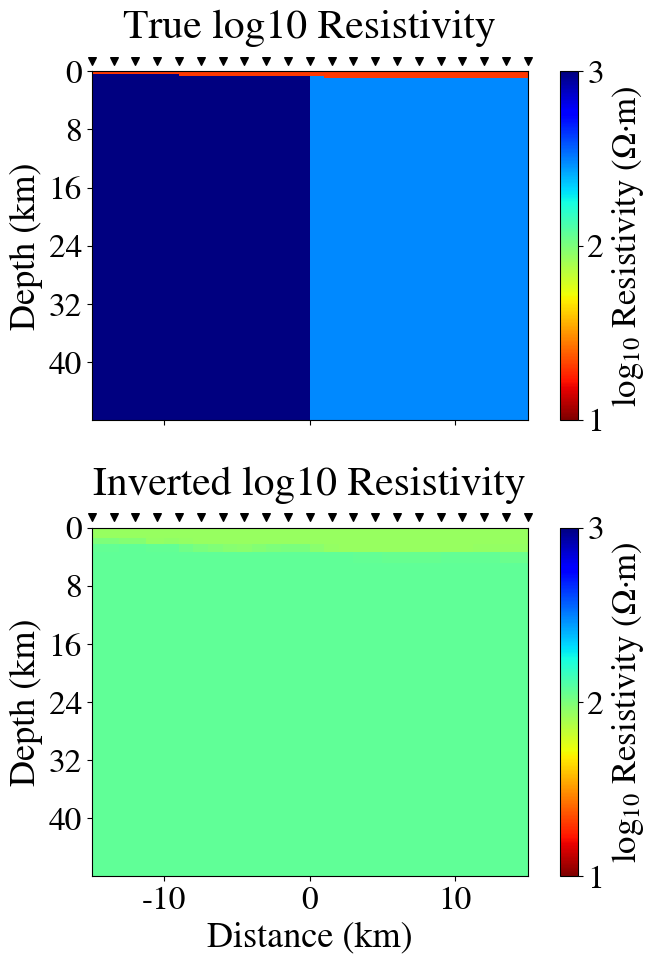

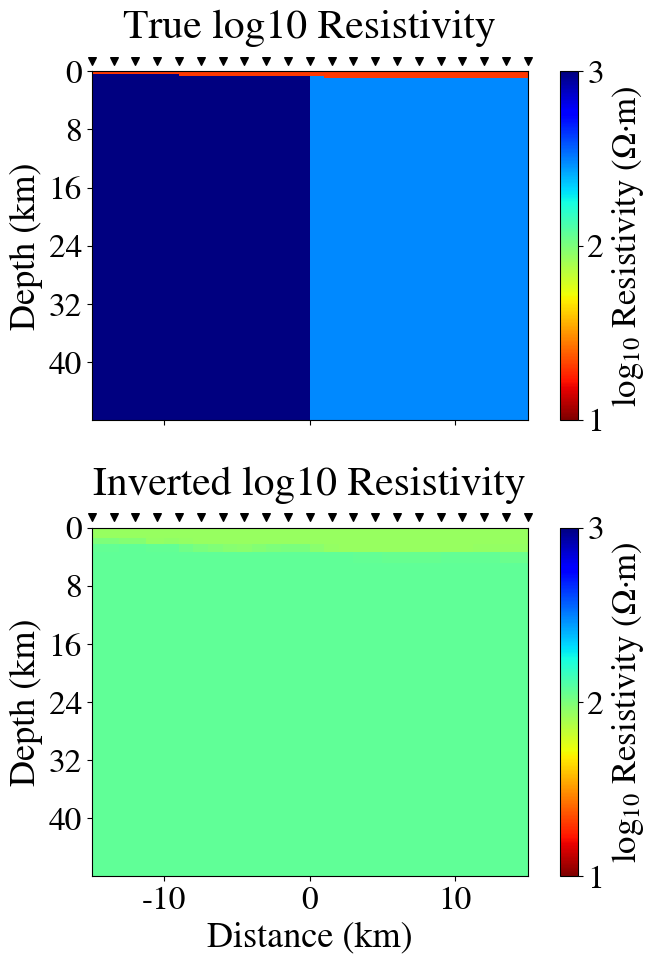

In [6]:
# 5a) OT 结果绘图
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0,
)
# inv.plot_data_fitting(stations_per_figure=4)
# inv.plot_1d_profiles(depth_limit_km=50)
# inv.plot_gradient_history()

In [7]:
# 6a) 保存 OT 结果
ot_run_dir = logger.save_from_inverter(inv, run_name="ot_21_4shift0.2")
history_ot = list(inv.loss_history)
print(f"OT run saved: {ot_run_dir}")


Saving results to: test_results/test/2026-07-25_04-44-02_ot_21_4shift0.2
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz
Model structural similarity (SSIM): 0.5345
  ✓ model_comparison.png/.pdf
  ✓ initial_model.png/.pdf
  ✓ data_fitting: 7 plots saved to test_results/test/2026-07-25_04-44-02_ot_21_4shift0.2/figures/data_fitting (21 stations)
  ✓ profiles_1d.png/.pdf
  ✓ Figures saved to test_results/test/2026-07-25_04-44-02_ot_21_4shift0.2/figures

Results saved successfully!
  Location: test_results/test/2026-07-25_04-44-02_ot_21_4shift0.2
  Final RMS χ²: 60.3391
  RMSE: 1.0262
  MAPE: 33.51%

OT run saved: test_results/test/2026-07-25_04-44-02_ot_21_4shift0.2


In [8]:
# 4b) MSE 反演（同一静位移观测数据，重置初模）
inv.initialize_model(initial_sigma=0.01)
final_sigma_mse = inv.run_inversion(
    n_epochs=3,
    mode="mse",
    progress_interval=20,
    current_lambda=1,
    use_adaptive_lambda=True,
    lr=0.05,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    profile_timing=False,
)
print("MSE inversion done")
print(final_sigma_mse.min().item(), final_sigma_mse.max().item())

✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m
✓ Optimizer: AdamW, lr=0.05, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.05, weight_decay=0.0
Epoch 1/3 [  33.3%]
  Elapsed: 0:00:01 | Remaining: ~0:00:02 | ETA: 04:44:35
  Epoch time: 1.26s | Avg: 1.26s
  Total: 2.3835e+01 | Data(mse): 2.3835e+01
  [Cost weights] w_s=1.000, w_f=1.000, w_d=(1.0, 1.0, 1.0, 1.0)
  Misfit(RMS χ²): 65.192 | Rough: 0.00e+00 | Lam: 1.0000000
  OT-distance(6D, view-only): 5.670822e+01
  GradNorms: |g_d|=nan | |λ·g_m|=nan
Epoch 3/3 [ 100.0%]
  Elapsed: 0:00:03 | Remaining: ~0:00:00 | ETA: 04:44:35
  Epoch time: 1.27s | Avg: 1.27s
  Total: 2.1369e+01 | Data(mse): 2.1079e+01
  Misfit(RMS χ²): 59.501 | Rough: 2.89e-01 | Lam: 1.0000000
  OT-distance(6D, view-only): 5.024319e+01
  GradNorms: |g_d|=nan | |λ·g_m|=nan
Inversion completed.
MSE inversion done
1e-10 0.011621187391576582


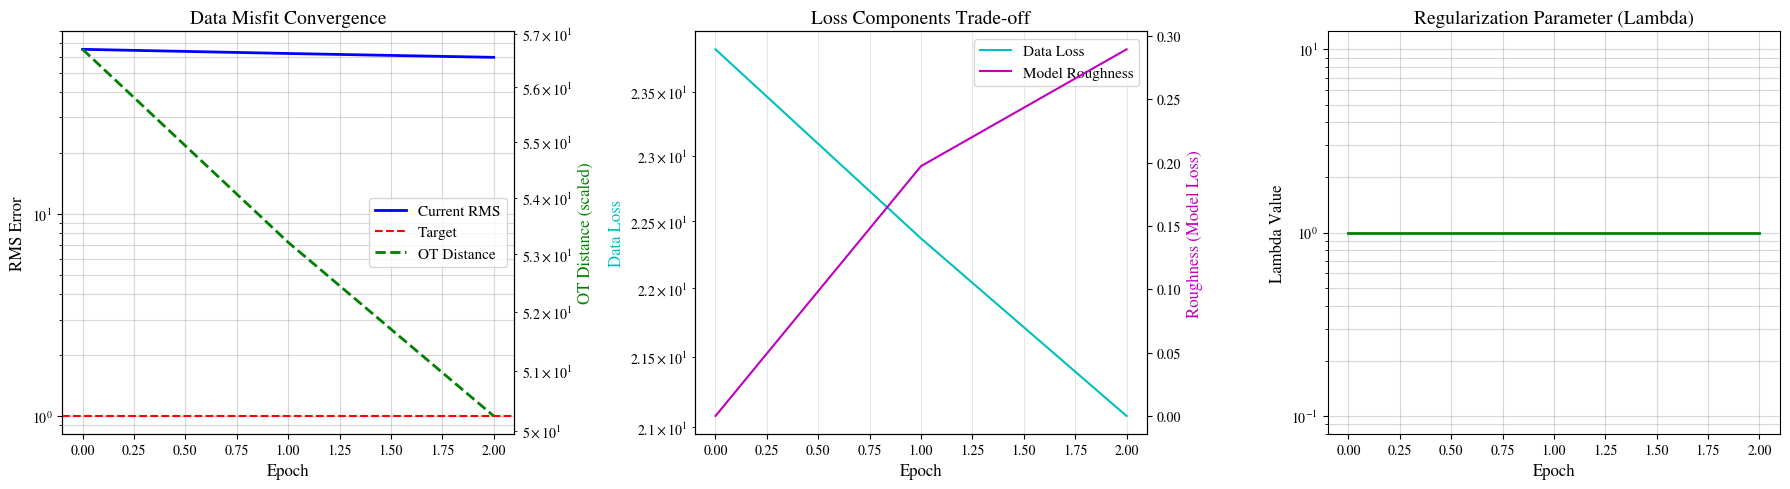

Model structural similarity (SSIM): 0.5587


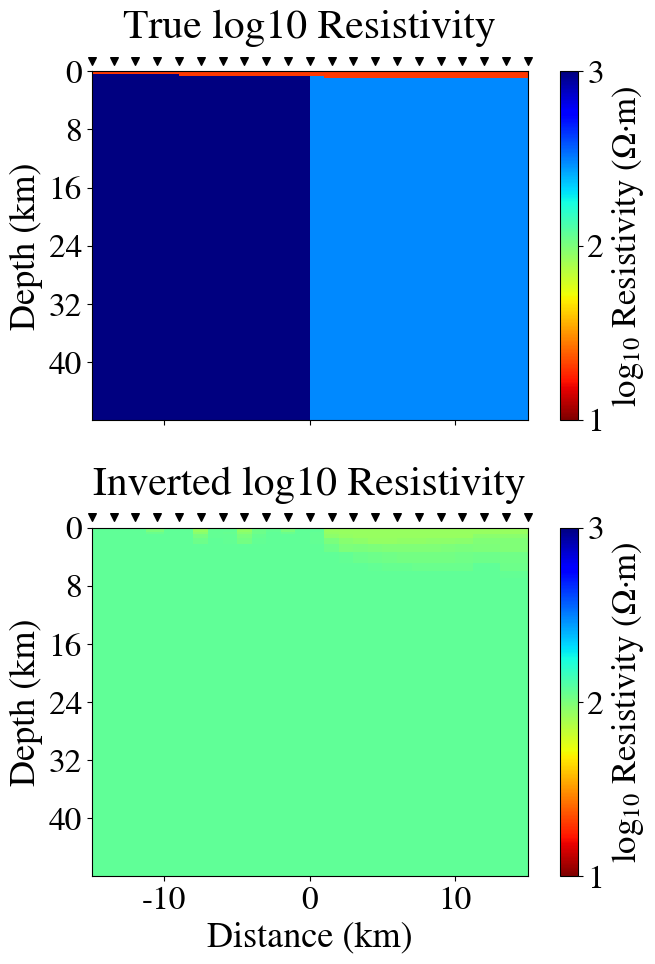

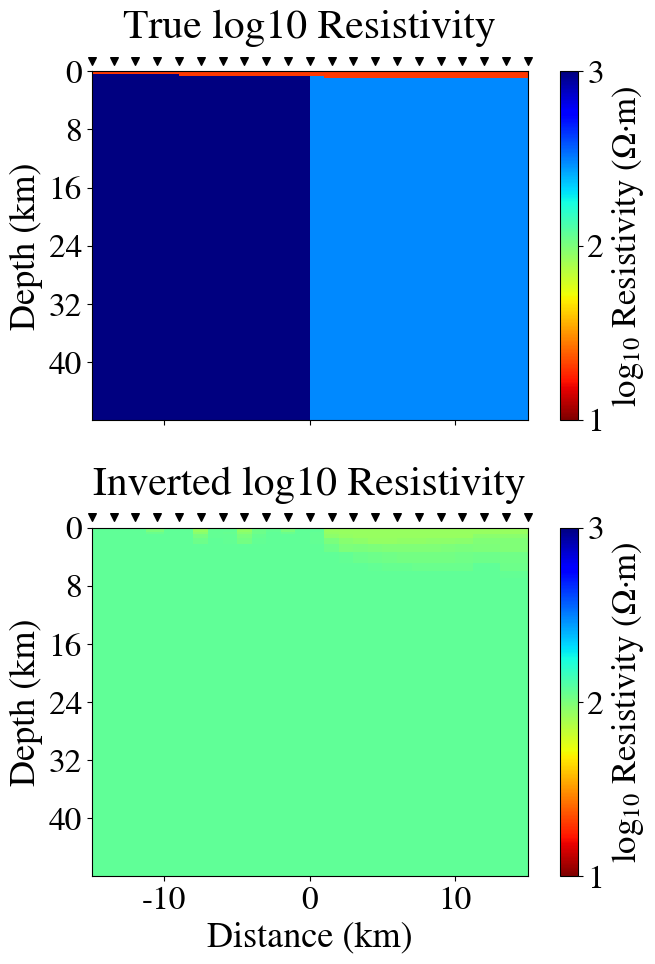

In [9]:
# 5b) MSE 结果绘图
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0,
)
# inv.plot_data_fitting(stations_per_figure=4)
# inv.plot_1d_profiles(depth_limit_km=50)
# inv.plot_gradient_history()

In [10]:
# 6b) 保存 MSE 结果
mse_run_dir = logger.save_from_inverter(inv, run_name="mse21_4shift0.2")
history_mse = list(inv.loss_history)
print(f"MSE run saved: {mse_run_dir}")


Saving results to: test_results/test/2026-07-25_04-44-36_mse21_4shift0.2
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz
Model structural similarity (SSIM): 0.5587
  ✓ model_comparison.png/.pdf
  ✓ initial_model.png/.pdf
  ✓ data_fitting: 7 plots saved to test_results/test/2026-07-25_04-44-36_mse21_4shift0.2/figures/data_fitting (21 stations)
  ✓ profiles_1d.png/.pdf
  ✓ Figures saved to test_results/test/2026-07-25_04-44-36_mse21_4shift0.2/figures

Results saved successfully!
  Location: test_results/test/2026-07-25_04-44-36_mse21_4shift0.2
  Final RMS χ²: 59.5014
  RMSE: 1.0198
  MAPE: 33.61%

MSE run saved: test_results/test/2026-07-25_04-44-36_mse21_4shift0.2


/home/liuxr/论文绘图/src/mt2d_inv/plotting/pseudosection.py:145: UserWarning: Glyph 8336 (\N{LATIN SUBSCRIPT SMALL LETTER A}) missing from font(s) STIXGeneral.
  ax.figure.tight_layout()
/home/liuxr/.conda/envs/torch/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8336 (\N{LATIN SUBSCRIPT SMALL LETTER A}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)


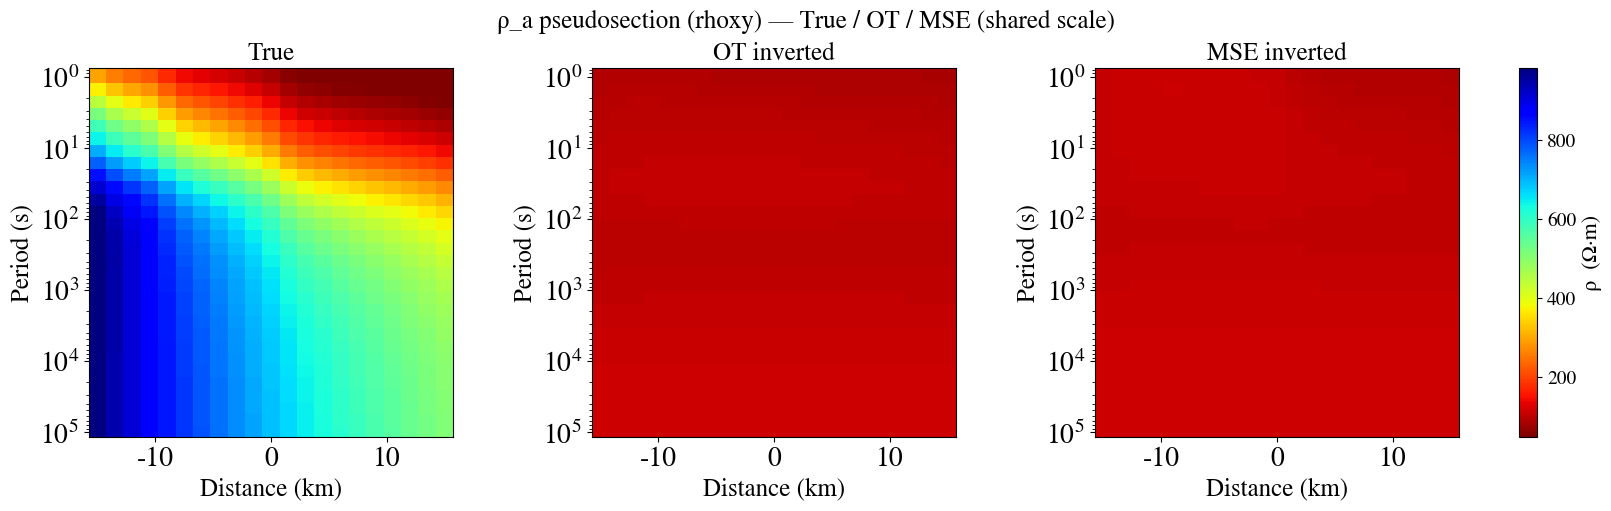

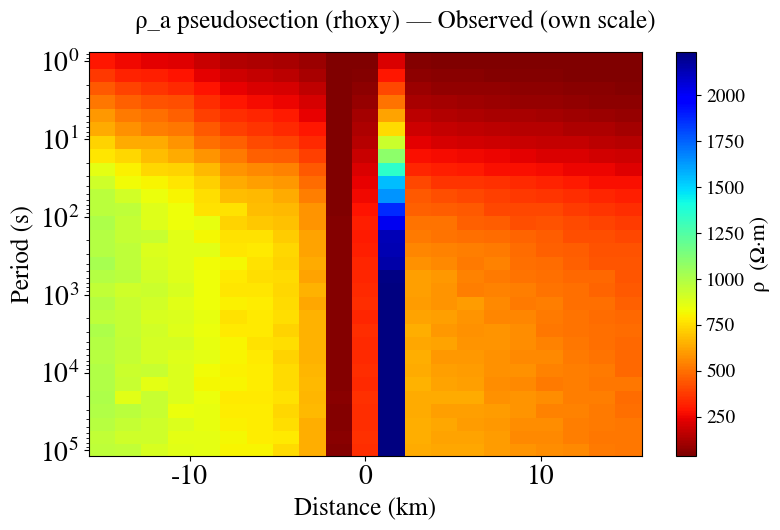

{'inversion_axes': array([<Axes: title={'center': 'True'}, xlabel='Distance (km)', ylabel='Period (s)'>,
        <Axes: title={'center': 'OT inverted'}, xlabel='Distance (km)', ylabel='Period (s)'>,
        <Axes: title={'center': 'MSE inverted'}, xlabel='Distance (km)', ylabel='Period (s)'>],
       dtype=object),
 'observed_axes': <Axes: xlabel='Distance (km)', ylabel='Period (s)'>}

In [2]:
import os
import sys
import torch
from pathlib import Path
import numpy as np

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "mt2d_inv" / "__init__.py").is_file():
            return p
    raise RuntimeError("Cannot find project root (expected src/mt2d_inv/__init__.py)")

root_path = str(_find_project_root(Path.cwd()))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

from src.mt2d_inv import MT2DInverterWeightedCost, MT2DTrueModels
from src.mt2d_inv.io import ExperimentLogger
from src.mt2d_inv.plotting import (
    plot_ot_mse_convergence,
    plot_ot_mse_convergence_from_dirs,
    plot_rho_fitting_from_npz,
    plot_ot_mse_pseudosection_from_npz,
)

logger = ExperimentLogger(
    model_tag="test",
    output_root=Path("test_results"),
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device}")
print(f"Project root: {root_path}")

# 7) OT vs MSE 对比（收敛曲线 + 视电阻率四线合一 + 伪断面）
# plot_ot_mse_convergence(history_ot, history_mse, target_misfit=1.05)

# plot_rho_fitting_from_npz(
#     "test_results/test/2026-07-25_04-44-02_ot_21_4shift0.2/apparent_resistivity.npz",
#     "test_results/test/2026-07-25_04-44-36_mse21_4shift0.2/apparent_resistivity.npz",
#     station_idx=11,
#     mode="xy",
# )
# plot_rho_fitting_from_npz(
#     "test_results/test/2026-07-25_04-44-02_ot_21_4shift0.2/apparent_resistivity.npz",
#     "test_results/test/2026-07-25_04-44-36_mse21_4shift0.2/apparent_resistivity.npz",
#     station_idx=11,
#     mode="yx",
# )

plot_ot_mse_pseudosection_from_npz(
    "test_results/test/2026-07-25_04-44-02_ot_21_4shift0.2/apparent_resistivity.npz",
    "test_results/test/2026-07-25_04-44-36_mse21_4shift0.2/apparent_resistivity.npz",
    mode="xy",
)